# Preparando o ambiente

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Análise exploratória

In [5]:
df = pd.read_csv('Base_de_dados_filtrada_projeto_data_science (1).csv')
df.head()

,TrackId,Nome_faixa,Titulo_album,Nome_artista,Nome_genero,Duracao_milissegundos,Duracao_minutos,preco_unitario
0,1,For Those About To Rock (We Salute You),For Those About To Rock We Salute You,AC/DC,Rock,343719,5.73,4.29
1,2,Balls to the Wall,Balls to the Wall,Accept,Rock,342562,5.71,4.42
2,3,Fast As a Shark,Restless and Wild,Accept,Rock,230619,3.84,2.91
3,4,Restless and Wild,Restless and Wild,Accept,Rock,252051,4.20,3.01
4,5,Princess of the Dawn,Restless and Wild,Accept,Rock,375418,6.26,4.58


In [6]:
df = pd.get_dummies(df, columns=['Nome_genero'], drop_first=True)

In [7]:
df.head()

,TrackId,Nome_faixa,Titulo_album,Nome_artista,Duracao_milissegundos,Duracao_minutos,preco_unitario,Nome_genero_Alternative & Punk,Nome_genero_Blues,Nome_genero_Bossa Nova,...,Nome_genero_Pop,Nome_genero_R&B/Soul,Nome_genero_Reggae,Nome_genero_Rock,Nome_genero_Rock And Roll,Nome_genero_Sci Fi & Fantasy,Nome_genero_Science Fiction,Nome_genero_Soundtrack,Nome_genero_TV Shows,Nome_genero_World
0,1,For Those About To Rock (We Salute You),For Those About To Rock We Salute You,AC/DC,343719,5.73,4.29,False,False,False,...,False,False,False,True,False,False,False,False,False,False
1,2,Balls to the Wall,Balls to the Wall,Accept,342562,5.71,4.42,False,False,False,...,False,False,False,True,False,False,False,False,False,False
2,3,Fast As a Shark,Restless and Wild,Accept,230619,3.84,2.91,False,False,False,...,False,False,False,True,False,False,False,False,False,False
3,4,Restless and Wild,Restless and Wild,Accept,252051,4.20,3.01,False,False,False,...,False,False,False,True,False,False,False,False,False,False
4,5,Princess of the Dawn,Restless and Wild,Accept,375418,6.26,4.58,False,False,False,...,False,False,False,True,False,False,False,False,False,False


# Identificando e removendo *outliers*

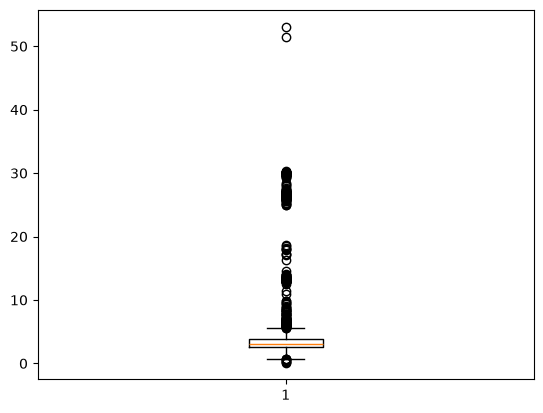

In [8]:
plt.boxplot(df['preco_unitario'])
plt.show()

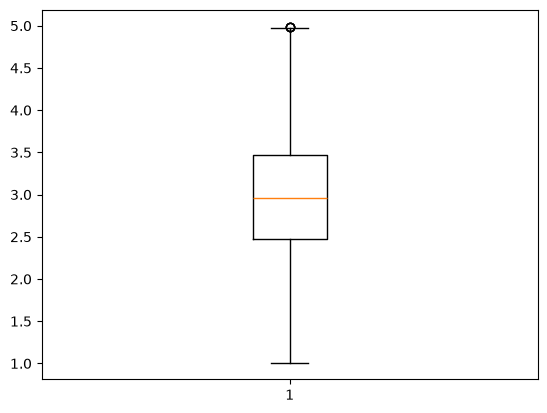

In [9]:
df = df[(df['preco_unitario'] > 1) & (df['preco_unitario'] < 5.0)]
plt.boxplot(df['preco_unitario'])
plt.show()

# Criação do modelo

In [10]:
colunas_generos = [c for c in df.columns if 'Nome_genero_' in c]


In [11]:
X = df[colunas_generos]
y = df['preco_unitario']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3)


In [12]:
from sklearn.linear_model import LinearRegression
modelo = LinearRegression()
modelo.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](24,)","[-0.12, 0.25,-0.27,..., 0.07, 0. ,-0.11]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](24,)","['Nome_genero_Alternative & Punk','Nome_genero_Blues', 'Nome_genero_Bossa Nova',...,'Nome_genero_Soundtrack', 'Nome_genero_TV Shows','Nome_genero_World']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.883
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,24
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(19)


In [13]:
coeficientes = pd.DataFrame({
    'Genero': X.columns,
    'Impacto_no_preco': modelo.coef_
})

coeficientes.sort_values(by='Impacto_no_preco', ascending=False)


,Genero,Impacto_no_preco
7,Nome_genero_Electronica/Dance,6.907675e-01
8,Nome_genero_Heavy Metal,5.764167e-01
12,Nome_genero_Metal,4.533435e-01
1,Nome_genero_Blues,2.516116e-01
17,Nome_genero_Rock,2.480522e-01
10,Nome_genero_Jazz,1.732197e-01
3,Nome_genero_Classical,1.593282e-01
16,Nome_genero_Reggae,8.483333e-02
21,Nome_genero_Soundtrack,7.008333e-02
4,Nome_genero_Comedy,5.551115e-17


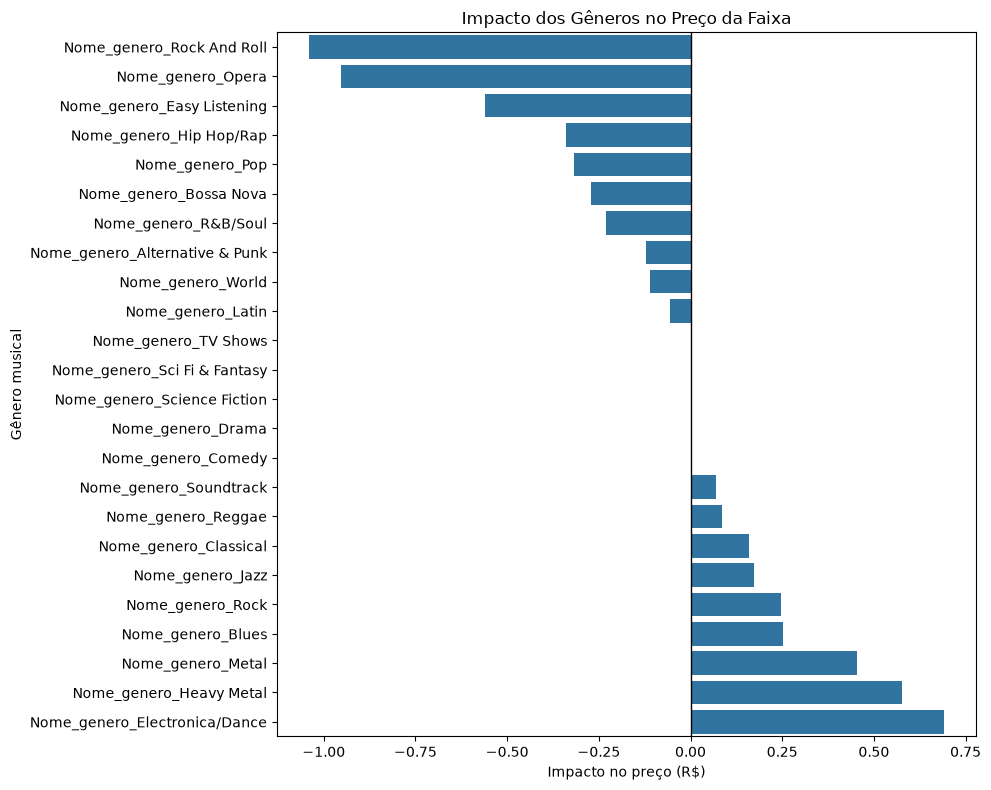

In [14]:
coef_plot = coeficientes.sort_values(by='Impacto_no_preco', ascending=True)

plt.figure(figsize=(10, 8))
sns.barplot(
    data=coef_plot,
    x='Impacto_no_preco',
    y='Genero'
)

plt.title("Impacto dos Gêneros no Preço da Faixa")
plt.xlabel("Impacto no preço (R$)")
plt.ylabel("Gênero musical")
plt.axvline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()